## 4 - Bayesian Models for RUL Prediction (Uncertainty Quantification)

**Goal:** move beyond point predictions (Notebook 3) to models that output a **predictive distribution** — mean *and* uncertainty — so RUL predictions come with a confidence band, and so we can check whether that uncertainty is honest (wide when the model should be unsure, narrow when it shouldn't).

**Planned models** (simple → complex, same progression as NB3):
1. **Bayesian Ridge Regression** — closed-form, flat features (this notebook, implemented below)
2. **Gaussian Process Regression** — flat features, non-parametric, full Bayesian treatment (next)
3. **MC Dropout LSTM** — sequence features, extends the NB3 LSTM backbone (next)

**Shared uncertainty metrics** (defined once, reused for every model): PICP, MPIW, NLL, CRPS.

**Robustness check (later):** evaluate on test1 (via `process_test1_for_robustness()` from NB2) — a genuinely out-of-distribution run. A well-calibrated Bayesian model should show *wider* uncertainty there, not just wrong point predictions.

#### 1. Data Loading

In [37]:
# Standard library
import os, re, time, pickle, warnings

# Core
import numpy as np
import pandas as pd
from scipy.stats import norm

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Bayesian models
from sklearn.linear_model import BayesianRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
np.random.seed(SEED)

In [38]:
# Load the same ML-ready artifacts NB3 used, so results are directly comparable
PREP_DIR     = './preprocessing_output'
BASELINE_DIR = './baseline_output'
OUT_DIR      = './bayesian_output'
os.makedirs(OUT_DIR, exist_ok=True)

flat = np.load(os.path.join(PREP_DIR, 'flat.npz'))
seq  = np.load(os.path.join(PREP_DIR, 'sequences.npz'))
with open(os.path.join(PREP_DIR, 'metadata.pkl'), 'rb') as f:
    META = pickle.load(f)

# Flat (tabular) arrays — for Bayesian Ridge / Gaussian Process
Xf_train, yf_train = flat['X_train'], flat['y_train']
Xf_val,   yf_val   = flat['X_val'],   flat['y_val']
Xf_test,  yf_test  = flat['X_test'],  flat['y_test']

# Sequence arrays — for MC Dropout LSTM (later section)
Xs_train, ys_train = seq['X_train'], seq['y_train']
Xs_val,   ys_val   = seq['X_val'],   seq['y_val']
Xs_test,  ys_test  = seq['X_test'],  seq['y_test']

# LDS sample weights, train only (None if NB2 didn't export any)
sw_flat = flat['sample_weight_train'] if 'sample_weight_train' in flat.files else None
sw_seq  = seq['sample_weight_train']  if 'sample_weight_train'  in seq.files  else None

FEATURE_COLS = META['feature_cols']
MAX_RUL_TEST = float(META['max_rul_per_test']['test3'])   # minutes, for de-normalisation
SNAPSHOT_MIN = 10.0   # IMS recording interval, used to express RUL in 'cycles' for scoring

print(f'Flat : train {Xf_train.shape} | val {Xf_val.shape} | test {Xf_test.shape}')
print(f'Seq  : train {Xs_train.shape} | val {Xs_val.shape} | test {Xs_test.shape}')
print(f'n_features = {len(FEATURE_COLS)} | MAX_RUL(test3) = {MAX_RUL_TEST:.0f} min')

Flat : train (788, 15) | val (196, 15) | test (6324, 15)
Seq  : train (730, 30, 15) | val (138, 30, 15) | test (6295, 30, 15)
n_features = 15 | MAX_RUL(test3) = 1520 min


In [39]:
# Load NB3 baseline results, to overlay / compare point-prediction performance
baseline_summary = pd.read_csv(os.path.join(BASELINE_DIR, 'baseline_results.csv'))
baseline_preds   = np.load(os.path.join(BASELINE_DIR, 'baseline_predictions.npz'))
print('Baseline (NB3) results loaded:')
print(baseline_summary.to_string(index=False))

Baseline (NB3) results loaded:
                 Model  RMSE_norm  MAE_norm  RMSE_min  MAE_min  Asym_score  Train_time_s  Pred_time_s
Mean predictor (floor)     0.1756    0.1682     266.9    255.7   3537111.5         0.000       0.0000
     Linear Regression     0.1727    0.0864     262.5    131.3   2898165.9         0.003       0.0010
               XGBoost     0.0416    0.0120      63.3     18.2     14315.3         0.221       0.0114
                   MLP     0.0917    0.0135     139.3     20.5  41942601.4         1.762       0.0145
                  LSTM     0.0689    0.0173     104.8     26.3   1903346.9         8.751       0.2049


#### 2. Evaluation Utilities (point metrics + uncertainty metrics)

Point metrics (RMSE/MAE) are the same as NB3, so results stay comparable. On top of those, every Bayesian model also outputs a predictive **std** (`sigma`), so we add 4 standard uncertainty metrics, assuming a Gaussian predictive distribution `N(mu, sigma^2)`:

- **PICP** (Prediction Interval Coverage Probability) — what fraction of true values actually fall inside the model's own 95% interval? Should be ≈ 0.95 for a well-calibrated model. Too low = overconfident; too high = underconfident.
- **MPIW** (Mean Prediction Interval Width) — how wide is that interval on average? Given similar PICP, narrower is better (more useful/informative).
- **NLL** (Negative Log-Likelihood) — a single score combining both accuracy and calibration; lower is better.
- **CRPS** (Continuous Ranked Probability Score) — a proper scoring rule; lower is better; more robust than NLL to a badly-mis-scaled sigma.

In [40]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true, float) - np.asarray(y_pred, float)) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true, float) - np.asarray(y_pred, float))))

# fraction of true values that fall inside the model's own (1-alpha) interval
def picp(y_true, mu, sigma, confidence=0.95):
    z = norm.ppf(0.5 + confidence / 2)
    lower, upper = mu - z * sigma, mu + z * sigma
    inside = (y_true >= lower) & (y_true <= upper)
    return float(np.mean(inside))

# mean width of the (1-alpha) interval — informativeness, not accuracy
def mpiw(sigma, confidence=0.95):
    z = norm.ppf(0.5 + confidence / 2)
    return float(np.mean(2 * z * sigma))

# average negative log-likelihood under N(mu, sigma^2)
def gaussian_nll(y_true, mu, sigma):
    sigma = np.clip(sigma, 1e-6, None)
    ll = -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((y_true - mu) / sigma)**2
    return float(-np.mean(ll))

# closed-form CRPS for a Gaussian predictive distribution (Gneiting & Raftery, 2007)
def gaussian_crps(y_true, mu, sigma):
    sigma = np.clip(sigma, 1e-6, None)
    z = (y_true - mu) / sigma
    crps = sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    return float(np.mean(crps))

BAYES_RESULTS = []   # collector — one dict per Bayesian model

# point metrics (like NB3's eval_rul) plus uncertainty metrics; stores a result dict
def eval_rul_bayesian(name, y_true, mu, sigma, train_time=np.nan, pred_time=np.nan,
                       model=None, max_rul=MAX_RUL_TEST, confidence=0.95, note=''):
    y_true = np.asarray(y_true, float)
    mu     = np.clip(np.asarray(mu, float), 0.0, 1.0)
    sigma  = np.asarray(sigma, float)
    yt_min, yp_min = y_true * max_rul, mu * max_rul

    r = {
        'model_name': name, 'model': model,
        'rmse_norm': rmse(y_true, mu), 'mae_norm': mae(y_true, mu),
        'rmse_min':  rmse(yt_min, yp_min), 'mae_min': mae(yt_min, yp_min),
        'picp': picp(y_true, mu, sigma, confidence),
        'mpiw': mpiw(sigma, confidence),
        'nll':  gaussian_nll(y_true, mu, sigma),
        'crps': gaussian_crps(y_true, mu, sigma),
        'train_time': train_time, 'pred_time': pred_time,
        'y_true': y_true, 'y_pred': mu, 'sigma': sigma, 'note': note,
    }
    BAYES_RESULTS.append(r)
    print(f'{name}')
    print(f'  RMSE (norm) : {r["rmse_norm"]:.4f}   |  MAE (norm) : {r["mae_norm"]:.4f}')
    print(f'  RMSE (min)  : {r["rmse_min"]:.1f}    |  MAE (min)  : {r["mae_min"]:.1f}')
    print(f'  PICP (95%)  : {r["picp"]:.3f}   (target ≈ 0.95)')
    print(f'  MPIW        : {r["mpiw"]:.4f}  (norm RUL units)')
    print(f'  NLL         : {r["nll"]:.4f}   |  CRPS : {r["crps"]:.4f}')
    print(f'  Train time  : {train_time:.3f}s  |  Pred time : {pred_time:.4f}s')
    return r

#### 3. Bayesian Models

#### 3.1 Bayesian Ridge Regression

Bayesian counterpart of the Ridge baseline from NB3: same linear model, but places priors on the weights and noise precision, so `predict(..., return_std=True)` gives an analytic per-sample standard deviation — no sampling needed.

In [41]:
# Model Initialization + Training
# BayesianRidge.fit supports sample_weight directly (unlike MLPRegressor),
# so we use sw_flat the same way Linear Regression / XGBoost did in NB3 —
# no resampling trick needed here.
bridge_model = BayesianRidge(max_iter=300, compute_score=True)

t0 = time.time()
bridge_model.fit(Xf_train, yf_train, sample_weight=sw_flat)
bridge_train_time = time.time() - t0
print(f'Bayesian Ridge trained in {bridge_train_time:.3f}s '
      f'(alpha={bridge_model.alpha_:.4g}, lambda={bridge_model.lambda_:.4g})')

Bayesian Ridge trained in 0.015s (alpha=331.9, lambda=1410)


In [42]:
# Predict + Evaluate (return_std=True gives the analytic predictive std)
t0 = time.time()
bridge_mu, bridge_sigma = bridge_model.predict(Xf_test, return_std=True)
bridge_pred_time = time.time() - t0

res_bridge = eval_rul_bayesian('Bayesian Ridge', yf_test, bridge_mu, bridge_sigma,
                               bridge_train_time, bridge_pred_time, model=bridge_model)

Bayesian Ridge
  RMSE (norm) : 0.0951   |  MAE (norm) : 0.0243
  RMSE (min)  : 144.6    |  MAE (min)  : 36.9
  PICP (95%)  : 0.974   (target ≈ 0.95)
  MPIW        : 0.3859  (norm RUL units)
  NLL         : -1.2570   |  CRPS : 0.0364
  Train time  : 0.015s  |  Pred time : 0.0036s


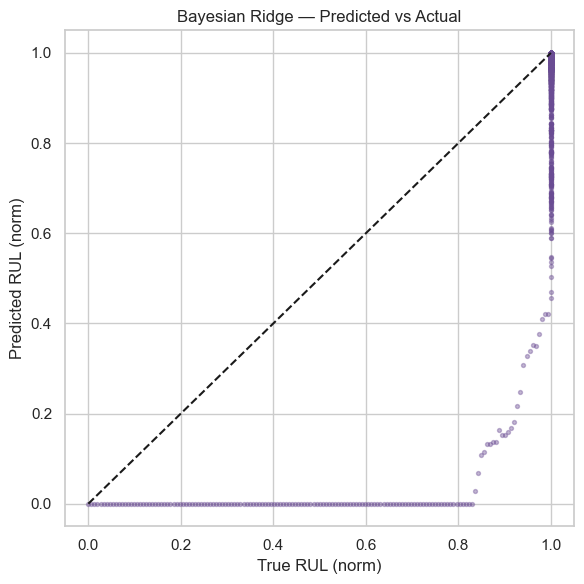

In [43]:
# Visualize — Predicted vs Actual (same convention as NB3: True=x, Predicted=y)
plt.figure(figsize=(6,6))
plt.scatter(res_bridge['y_true'], res_bridge['y_pred'], s=8, alpha=0.4, color='#6a4c93')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('True RUL (norm)'); plt.ylabel('Predicted RUL (norm)')
plt.title('Bayesian Ridge — Predicted vs Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fit_bayesianridge.png'), dpi=150, bbox_inches='tight')
plt.show()

**Uncertainty visualization** — this is the plot point-prediction models (NB3) couldn't produce: RUL over time with a shaded 95% confidence band. Zoomed to the first `n` samples (same zoom-in pattern used in NB3) since 6000+ points would hide the band entirely.

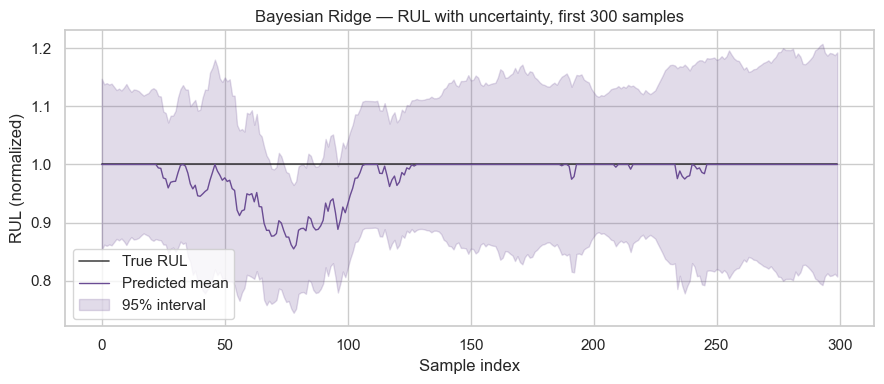

In [44]:
n = 300
idx_plot = np.arange(n)
z95 = norm.ppf(0.975)   # z-score for a 95% interval

plt.figure(figsize=(9,4))
plt.plot(idx_plot, res_bridge['y_true'][:n], color='black', lw=1.2, alpha=0.7, label='True RUL')
plt.plot(idx_plot, res_bridge['y_pred'][:n], color='#6a4c93', lw=1.0, label='Predicted mean')
# shaded band = predicted mean +/- 95% interval, built from the model's own sigma
plt.fill_between(idx_plot,
                  res_bridge['y_pred'][:n] - z95 * res_bridge['sigma'][:n],
                  res_bridge['y_pred'][:n] + z95 * res_bridge['sigma'][:n],
                  color='#6a4c93', alpha=0.2, label='95% interval')
plt.title(f'Bayesian Ridge — RUL with uncertainty, first {n} samples')
plt.xlabel('Sample index'); plt.ylabel('RUL (normalized)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'uncertainty_bayesianridge.png'), dpi=150, bbox_inches='tight')
plt.show()

**Reading these results:** compare `rmse_norm` above against Ridge's point RMSE in `baseline_summary` — they should be close (same underlying linear model). The new information is PICP/MPIW/NLL/CRPS: if PICP is far from 0.95, the model's uncertainty is mis-calibrated even if its point predictions are fine.

#### 3.2 Gaussian Process Regression

Non-parametric Bayesian model — instead of assuming a fixed functional form (linear, like Bayesian Ridge), GP places a prior directly over *functions* and updates it with data, giving a full predictive distribution at every point. Good fit for a small tabular dataset like this one (788 train rows).

In [45]:
# Model Initialization + Training
# GaussianProcessRegressor.fit() has no sample_weight argument at all (unlike
# BayesianRidge), so we reuse the same resampling-by-weight trick from the
# MLP fix in NB3 to address class imbalance. We ALSO add a dedicated
# StandardScaler (same rationale as MLP/LSTM in NB3): GP's kernel
# hyperparameters (length-scale, amplitude) are fit by gradient-based MLE on
# the marginal likelihood, so wildly uneven feature scale hurts it the same
# way it hurt MLP/LSTM. This scaler is local to this cell only.
from sklearn.gaussian_process.kernels import Matern

rng_gp = np.random.default_rng(SEED)
idx_gp = rng_gp.choice(len(Xf_train), size=len(Xf_train), replace=True, p=sw_flat / sw_flat.sum())

gp_scaler   = StandardScaler().fit(Xf_train[idx_gp])
Xf_train_gp = gp_scaler.transform(Xf_train[idx_gp])
Xf_test_gp  = gp_scaler.transform(Xf_test)
y_train_gp  = yf_train[idx_gp]

# Matern(nu=1.5) is a common default for physical/sensor data (less smooth
# than RBF); WhiteKernel lets the GP learn its own observation-noise level
# instead of assuming the data is noise-free.
kernel = (ConstantKernel(1.0, (1e-2, 1e2)) *
          Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=1.5) +
          WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1.0)))

gp_model = GaussianProcessRegressor(kernel=kernel, normalize_y=True,
                                     n_restarts_optimizer=3, random_state=SEED)

t0 = time.time()
gp_model.fit(Xf_train_gp, y_train_gp)
gp_train_time = time.time() - t0
print(f'GP trained in {gp_train_time:.3f}s')
print(f'Learned kernel: {gp_model.kernel_}')

GP trained in 15.432s
Learned kernel: 6.11**2 * Matern(length_scale=43.1, nu=1.5) + WhiteKernel(noise_level=1e-06)


In [46]:
# Predict + Evaluate (return_std=True gives the analytic predictive std)
t0 = time.time()
gp_mu, gp_sigma = gp_model.predict(Xf_test_gp, return_std=True)
gp_pred_time = time.time() - t0

res_gp = eval_rul_bayesian('Gaussian Process', yf_test, gp_mu, gp_sigma,
                            gp_train_time, gp_pred_time, model=gp_model)

Gaussian Process
  RMSE (norm) : 0.0524   |  MAE (norm) : 0.0135
  RMSE (min)  : 79.7    |  MAE (min)  : 20.5
  PICP (95%)  : 0.999   (target ≈ 0.95)
  MPIW        : 0.2710  (norm RUL units)
  NLL         : -1.9410   |  CRPS : 0.0192
  Train time  : 15.432s  |  Pred time : 0.4262s


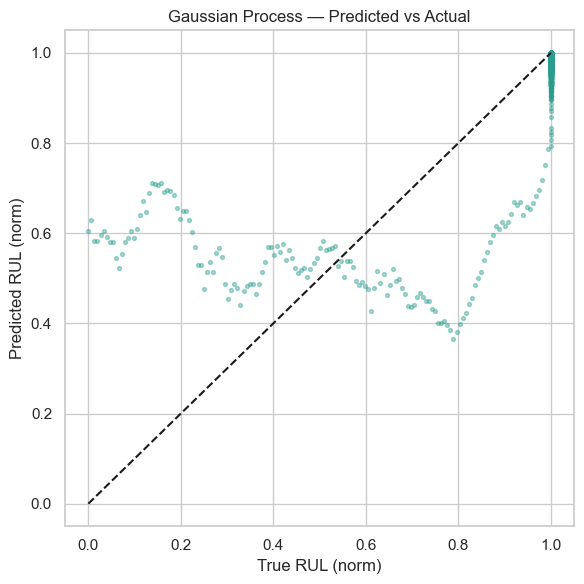

In [47]:
# Visualize — Predicted vs Actual
plt.figure(figsize=(6,6))
plt.scatter(res_gp['y_true'], res_gp['y_pred'], s=8, alpha=0.4, color='#2a9d8f')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('True RUL (norm)'); plt.ylabel('Predicted RUL (norm)')
plt.title('Gaussian Process — Predicted vs Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fit_gp.png'), dpi=150, bbox_inches='tight')
plt.show()

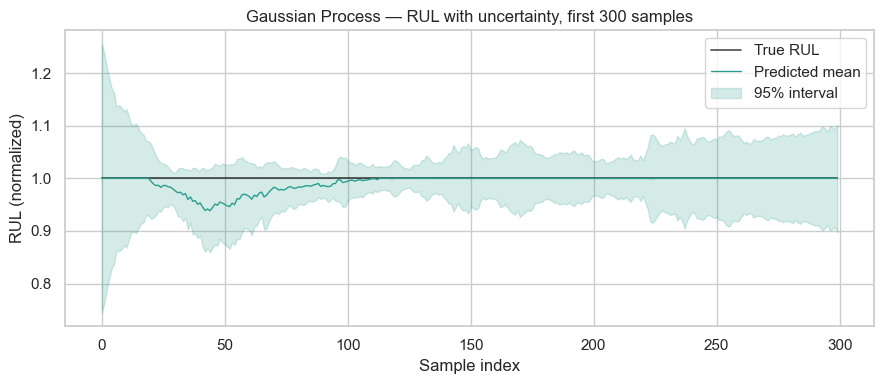

In [48]:
# Visualize — RUL with uncertainty band, zoomed (same convention as Bayesian Ridge)
n = 300
idx_plot = np.arange(n)
z95 = norm.ppf(0.975)

plt.figure(figsize=(9,4))
plt.plot(idx_plot, res_gp['y_true'][:n], color='black', lw=1.2, alpha=0.7, label='True RUL')
plt.plot(idx_plot, res_gp['y_pred'][:n], color='#2a9d8f', lw=1.0, label='Predicted mean')
plt.fill_between(idx_plot,
                  res_gp['y_pred'][:n] - z95 * res_gp['sigma'][:n],
                  res_gp['y_pred'][:n] + z95 * res_gp['sigma'][:n],
                  color='#2a9d8f', alpha=0.2, label='95% interval')
plt.title(f'Gaussian Process — RUL with uncertainty, first {n} samples')
plt.xlabel('Sample index'); plt.ylabel('RUL (normalized)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'uncertainty_gp.png'), dpi=150, bbox_inches='tight')
plt.show()

#### 3.3 MC Dropout LSTM

Reuses the LSTM backbone trained in NB3 (`lstm_baseline.pt`) — same architecture, same weights. The trick: keep **dropout active at inference** (normally `model.eval()` turns dropout off) and run many stochastic forward passes on the same input. Each pass is a slightly different random sub-network, so the spread across passes approximates a Bayesian posterior over predictions (Gal & Ghahramani, 2016).

In [49]:
# Setup — same architecture as NB3, so the saved state_dict loads cleanly
import torch
import torch.nn as nn

torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class LSTMRegressor(nn.Module):
    def __init__(self, n_feat, hidden=64, layers=2, p=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, num_layers=layers,
                            batch_first=True, dropout=p if layers > 1 else 0.0)
        self.head = nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(),
                                  nn.Dropout(p), nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])   # use only the last timestep's output


In [50]:
# Re-fit the SAME sequence scaler NB3 used for LSTM (fit on Xs_train, applied
# to Xs_test). This isn't saved by NB3, but re-fitting here is equivalent:
# it's a deterministic fit on the same Xs_train loaded from sequences.npz.
n_feat_seq = Xs_train.shape[-1]
seq_scaler = StandardScaler().fit(Xs_train.reshape(-1, n_feat_seq))

# reshape to 2D for the scaler, then back to the original (samples, window, features) shape
def scale_seq(X, scaler=seq_scaler, n_feat=n_feat_seq):
    if len(X) == 0:
        return X
    shp = X.shape
    return scaler.transform(X.reshape(-1, n_feat)).reshape(shp).astype(np.float32)

Xs_test_lstm = scale_seq(Xs_test)
Xte = torch.tensor(Xs_test_lstm, dtype=torch.float32).to(device)

lstm_model = LSTMRegressor(Xte.shape[-1]).to(device)
lstm_model.load_state_dict(torch.load(os.path.join(BASELINE_DIR, 'lstm_baseline.pt'),
                                       map_location=device))
print('LSTM backbone loaded from NB3.')

LSTM backbone loaded from NB3.


In [51]:
# MC Dropout inference — keep dropout ON (model.train()) but no gradients,
# no optimizer steps: we're sampling stochastic forward passes, not training.
N_SAMPLES = 50
lstm_model.train()   # activates dropout at inference time -- the whole trick

t0 = time.time()
preds = np.zeros((N_SAMPLES, len(Xte)), dtype=np.float32)
with torch.no_grad():
    for i in range(N_SAMPLES):
        preds[i] = lstm_model(Xte).cpu().numpy().ravel()
mc_pred_time = time.time() - t0

mc_mu    = preds.mean(axis=0)
mc_sigma = preds.std(axis=0)
print(f'{N_SAMPLES} stochastic passes in {mc_pred_time:.2f}s | '
      f'mean sigma = {mc_sigma.mean():.4f}')

50 stochastic passes in 8.80s | mean sigma = 0.1267


In [52]:
# Evaluate
res_mc = eval_rul_bayesian('MC Dropout LSTM', ys_test, mc_mu, mc_sigma,
                           train_time=0.0, pred_time=mc_pred_time, model=lstm_model,
                           note=f'{N_SAMPLES} MC passes; backbone from NB3')

MC Dropout LSTM
  RMSE (norm) : 0.1157   |  MAE (norm) : 0.0501
  RMSE (min)  : 175.8    |  MAE (min)  : 76.2
  PICP (95%)  : 0.939   (target ≈ 0.95)
  MPIW        : 0.4966  (norm RUL units)
  NLL         : -0.1894   |  CRPS : 0.0547
  Train time  : 0.000s  |  Pred time : 8.7983s


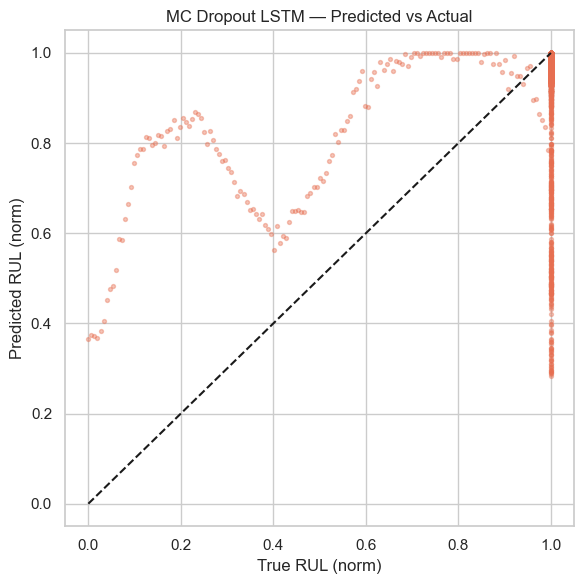

In [53]:
# Visualize — Predicted vs Actual
plt.figure(figsize=(6,6))
plt.scatter(res_mc['y_true'], res_mc['y_pred'], s=8, alpha=0.4, color='#e76f51')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('True RUL (norm)'); plt.ylabel('Predicted RUL (norm)')
plt.title('MC Dropout LSTM — Predicted vs Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fit_mcdropout_lstm.png'), dpi=150, bbox_inches='tight')
plt.show()

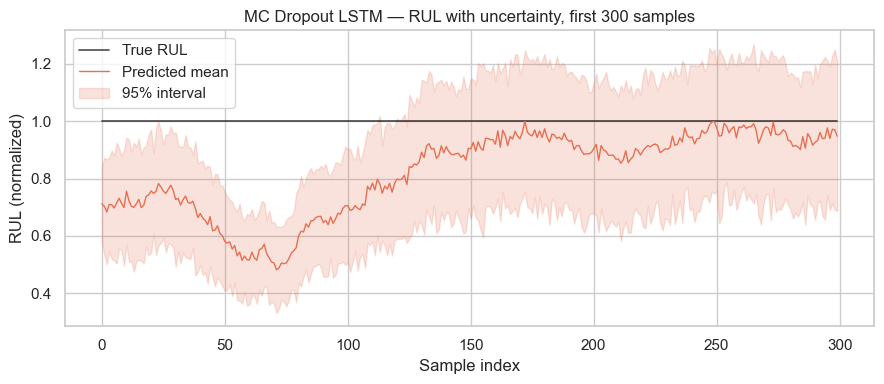

In [54]:
# Visualize — RUL with uncertainty band, zoomed
n = 300
idx_plot = np.arange(n)
z95 = norm.ppf(0.975)

plt.figure(figsize=(9,4))
plt.plot(idx_plot, res_mc['y_true'][:n], color='black', lw=1.2, alpha=0.7, label='True RUL')
plt.plot(idx_plot, res_mc['y_pred'][:n], color='#e76f51', lw=1.0, label='Predicted mean')
plt.fill_between(idx_plot,
                  res_mc['y_pred'][:n] - z95 * res_mc['sigma'][:n],
                  res_mc['y_pred'][:n] + z95 * res_mc['sigma'][:n],
                  color='#e76f51', alpha=0.2, label='95% interval')
plt.title(f'MC Dropout LSTM — RUL with uncertainty, first {n} samples')
plt.xlabel('Sample index'); plt.ylabel('RUL (normalized)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'uncertainty_mcdropout_lstm.png'), dpi=150, bbox_inches='tight')
plt.show()

#### 4. Summarisation

In [55]:
# Build comparison table across all 3 Bayesian models
bayes_summary = pd.DataFrame([
    {
        'Model'       : r['model_name'],
        'RMSE_norm'   : round(r['rmse_norm'], 4),
        'MAE_norm'    : round(r['mae_norm'],  4),
        'RMSE_min'    : round(r['rmse_min'],  1),
        'PICP_95'     : round(r['picp'], 3),
        'MPIW'        : round(r['mpiw'], 4),
        'NLL'         : round(r['nll'],  4),
        'CRPS'        : round(r['crps'], 4),
        'Train_time_s': round(r['train_time'], 3),
        'Pred_time_s' : round(r['pred_time'],  4),
    }
    for r in BAYES_RESULTS
])
print('Bayesian Model Comparison (test3):')
print(bayes_summary.to_string(index=False))
print()
print('For context — NB3 point-prediction baseline:')
print(baseline_summary.to_string(index=False))

Bayesian Model Comparison (test3):
           Model  RMSE_norm  MAE_norm  RMSE_min  PICP_95   MPIW     NLL   CRPS  Train_time_s  Pred_time_s
  Bayesian Ridge     0.0951    0.0243     144.6    0.974 0.3859 -1.2570 0.0364         0.015       0.0036
Gaussian Process     0.0524    0.0135      79.7    0.999 0.2710 -1.9410 0.0192        15.432       0.4262
 MC Dropout LSTM     0.1157    0.0501     175.8    0.939 0.4966 -0.1894 0.0547         0.000       8.7983

For context — NB3 point-prediction baseline:
                 Model  RMSE_norm  MAE_norm  RMSE_min  MAE_min  Asym_score  Train_time_s  Pred_time_s
Mean predictor (floor)     0.1756    0.1682     266.9    255.7   3537111.5         0.000       0.0000
     Linear Regression     0.1727    0.0864     262.5    131.3   2898165.9         0.003       0.0010
               XGBoost     0.0416    0.0120      63.3     18.2     14315.3         0.221       0.0114
                   MLP     0.0917    0.0135     139.3     20.5  41942601.4         1.76

**Reading this table:** compare `RMSE_norm` against the matching NB3 baseline row first (Bayesian Ridge vs Ridge (CV); MC Dropout LSTM vs LSTM) — point accuracy should be similar, since the backbone model is the same. The new columns are the payoff: **PICP** near 0.95 means the uncertainty is honest; **MPIW** tells you how *useful* that uncertainty is (narrower = more informative, for similar PICP); **NLL**/**CRPS** are single-number summaries for ranking models when PICP/MPIW trade off against each other.

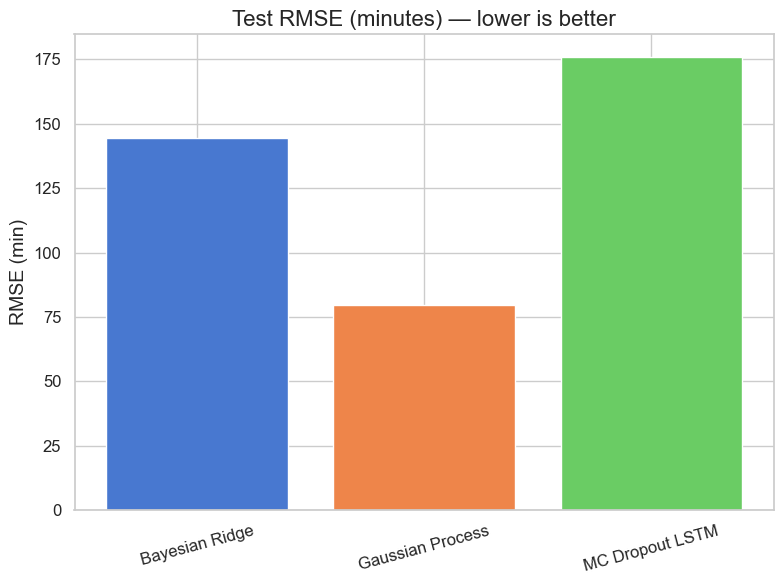

In [56]:
# Visualize Test RMSE comparison (bar chart) — Bayesian models

names = bayes_summary['Model'].tolist()

fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.bar(names, bayes_summary['RMSE_min'], color=sns.color_palette('muted', len(names)))
ax1.set_title('Test RMSE (minutes) — lower is better', fontsize=16)
ax1.set_ylabel('RMSE (min)', fontsize=14)
ax1.tick_params(axis='x', rotation=15, labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'bayesian_rmse_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()


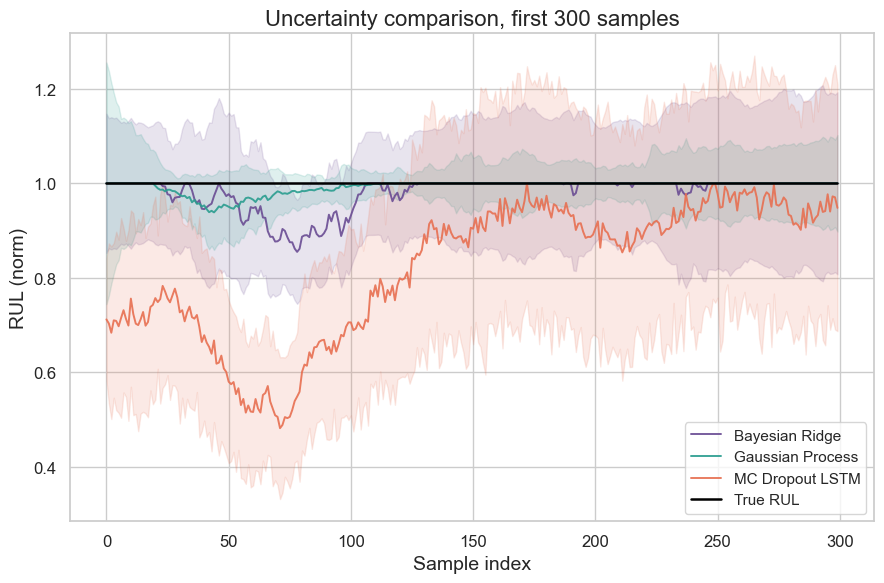

In [58]:
# Visualize Uncertainty band overlay (test3, first n samples)

n = 300
idx_plot = np.arange(n)
colors = {'Bayesian Ridge': '#6a4c93', 'Gaussian Process': '#2a9d8f', 'MC Dropout LSTM': '#e76f51'}

fig2, ax2 = plt.subplots(figsize=(9, 6))
for r in BAYES_RESULTS:
    c = colors.get(r['model_name'], '#457b9d')
    ax2.plot(idx_plot, r['y_pred'][:n], color=c, lw=1.4, label=r['model_name'], alpha=0.9)
    ax2.fill_between(idx_plot, r['y_pred'][:n] - 1.96 * r['sigma'][:n],
                      r['y_pred'][:n] + 1.96 * r['sigma'][:n], color=c, alpha=0.15)
ax2.plot(idx_plot, BAYES_RESULTS[0]['y_true'][:n], color='black', lw=1.8, label='True RUL')
ax2.set_title(f'Uncertainty comparison, first {n} samples', fontsize=16)
ax2.set_xlabel('Sample index', fontsize=14)
ax2.set_ylabel('RUL (norm)', fontsize=14)
ax2.tick_params(axis='both', labelsize=12)
ax2.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'bayesian_uncertainty_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()


In [59]:
# Save Bayesian results
bayes_summary.to_csv(os.path.join(OUT_DIR, 'bayesian_results.csv'), index=False)
np.savez_compressed(
    os.path.join(OUT_DIR, 'bayesian_predictions.npz'),
    **{f"{r['model_name'].split()[0]}__true":  r['y_true'] for r in BAYES_RESULTS},
    **{f"{r['model_name'].split()[0]}__pred":  r['y_pred'] for r in BAYES_RESULTS},
    **{f"{r['model_name'].split()[0]}__sigma": r['sigma']  for r in BAYES_RESULTS})
print('Saved to', os.path.abspath(OUT_DIR))
print('  bayesian_results.csv      -> metric table (RMSE/MAE + PICP/MPIW/NLL/CRPS)')
print('  bayesian_predictions.npz  -> per-model (true, pred, sigma)')

Saved to C:\Users\Windown\OneDrive - Aston University\1_Dissertation\1_Project_Dissertation\bayesian_output
  bayesian_results.csv      -> metric table (RMSE/MAE + PICP/MPIW/NLL/CRPS)
  bayesian_predictions.npz  -> per-model (true, pred, sigma)


#### 5. Robustness Testing — test1 (Out-of-Distribution)

test1 (B3 inner race + B4 roller failure) was reserved out of the main pipeline (NB2 Step 9) and never seen during training/validation of any of the 3 Bayesian models above — it's a genuinely different failure mode from test2/test3 (outer race). Evaluating on it checks whether the models' **uncertainty stays honest** when facing something unfamiliar, not just whether point predictions degrade.

Uses `robustness_test1_utils.load_test1_for_robustness()` — mirrors NB2's own `process_test1_for_robustness()`, but additionally returns the **flat** (unwindowed) arrays needed by Bayesian Ridge / GP, alongside the windowed sequence arrays for MC Dropout LSTM.

**What to look for:** a well-calibrated model should show *wider* intervals (higher MPIW) here than on test3, and PICP dropping (especially far below 0.95, i.e. overconfident) is the warning sign — it means the model doesn't know what it doesn't know.

In [60]:
import pickle
from robustness_test1_utils import load_test1_for_robustness

# saved by NB2 — paths/params needed to rebuild the test1 (OOD) arrays the same way
with open(os.path.join(PREP_DIR, 'robustness_config.pkl'), 'rb') as f:
    ROB_CONFIG = pickle.load(f)

# returns BOTH flat and windowed sequence versions of test1, for all 3 models
rob1 = load_test1_for_robustness(
    ROB_CONFIG['test1_dir'],
    ROB_CONFIG['feature_cols'],
    window_size=ROB_CONFIG['window_size'],
    healthy_n=ROB_CONFIG['healthy_n'],
)

Xf_test1, yf_test1 = rob1['X_flat'], rob1['y_flat']
Xs_test1, ys_test1 = rob1['X_seq'],  rob1['y_seq']
MAX_RUL_TEST1 = rob1['max_rul']   # test1 has its own run length, different from test3
print(f'MAX_RUL (test1, data-driven) = {MAX_RUL_TEST1:.0f} min')

=== Loading test1 for robustness testing (flat + sequence) ===
  [test1] bandpass range (kurtogram, failing bearing, near-failure snapshot): 7662-7962 Hz (center=7812 Hz, peak SK=43.21)
  [test1] 2156 files | 8 channels | ch_map=[0, 2, 4, 6]
    200/2156 done...
    400/2156 done...
    600/2156 done...
    800/2156 done...
    1000/2156 done...
    1200/2156 done...
    1400/2156 done...
    1600/2156 done...
    1800/2156 done...
    2000/2156 done...
  [test1] ✓ 2156 valid samples | 827.6 hours
  [test1] Total=827.6h | FPT idx=676 (420.9h) | MAX_RUL=24398 min (data-driven)
  test1 flat : X(2156, 15)  y(2156,)
  test1 seq  : X(2127, 30, 15)  y(2127,)  (window_size=30)
MAX_RUL (test1, data-driven) = 24398 min


In [61]:
# Same metric computation as eval_rul_bayesian(), but appends to ROB_RESULTS
# (test1 / OOD) instead of BAYES_RESULTS (test3 / in-distribution) — keeps the
# two comparison tables from Step 4 and this section fully separate.
ROB_RESULTS = []

def eval_rul_robustness(name, y_true, mu, sigma, max_rul, note=''):
    y_true = np.asarray(y_true, float)
    mu     = np.clip(np.asarray(mu, float), 0.0, 1.0)
    sigma  = np.asarray(sigma, float)
    yt_min, yp_min = y_true * max_rul, mu * max_rul

    r = {
        'model_name': name,
        'rmse_norm': rmse(y_true, mu), 'mae_norm': mae(y_true, mu),
        'rmse_min':  rmse(yt_min, yp_min), 'mae_min': mae(yt_min, yp_min),
        'picp': picp(y_true, mu, sigma), 'mpiw': mpiw(sigma),
        'nll':  gaussian_nll(y_true, mu, sigma), 'crps': gaussian_crps(y_true, mu, sigma),
        'y_true': y_true, 'y_pred': mu, 'sigma': sigma, 'note': note,
    }
    ROB_RESULTS.append(r)
    print(f'{name}')
    print(f'  RMSE (norm) : {r["rmse_norm"]:.4f}   |  MAE (norm) : {r["mae_norm"]:.4f}')
    print(f'  RMSE (min)  : {r["rmse_min"]:.1f}    |  MAE (min)  : {r["mae_min"]:.1f}')
    print(f'  PICP (95%)  : {r["picp"]:.3f}   (target ≈ 0.95)')
    print(f'  MPIW        : {r["mpiw"]:.4f}')
    print(f'  NLL         : {r["nll"]:.4f}   |  CRPS : {r["crps"]:.4f}')
    return r

**5.1 Bayesian Ridge on test1**

In [62]:
# Bayesian Ridge needs no re-fitting — same model, just predicting on test1 now
bridge_mu1, bridge_sigma1 = bridge_model.predict(Xf_test1, return_std=True)
res_bridge_rob = eval_rul_robustness('Bayesian Ridge (test1 OOD)', yf_test1, bridge_mu1, bridge_sigma1,
                                     MAX_RUL_TEST1, note='robustness / OOD (test1)')

Bayesian Ridge (test1 OOD)
  RMSE (norm) : 0.4174   |  MAE (norm) : 0.3236
  RMSE (min)  : 10184.8    |  MAE (min)  : 7895.5
  PICP (95%)  : 0.640   (target ≈ 0.95)
  MPIW        : 4.0400
  NLL         : 2.4892   |  CRPS : 0.3693


**5.2 Gaussian Process on test1** (needs the same `gp_scaler` transform used at train/test3 time)

In [63]:
# must reuse gp_scaler fit on train — never re-fit a scaler on test data
Xf_test1_gp = gp_scaler.transform(Xf_test1)
gp_mu1, gp_sigma1 = gp_model.predict(Xf_test1_gp, return_std=True)
res_gp_rob = eval_rul_robustness('Gaussian Process (test1 OOD)', yf_test1, gp_mu1, gp_sigma1,
                                 MAX_RUL_TEST1, note='robustness / OOD (test1)')

Gaussian Process (test1 OOD)
  RMSE (norm) : 0.4525   |  MAE (norm) : 0.3462
  RMSE (min)  : 11039.0    |  MAE (min)  : 8446.6
  PICP (95%)  : 0.978   (target ≈ 0.95)
  MPIW        : 1.9380
  NLL         : 0.0289   |  CRPS : 0.2315


**5.3 MC Dropout LSTM on test1** (same `seq_scaler` + stochastic-pass procedure as test3)

In [64]:
Xs_test1_lstm = scale_seq(Xs_test1)
Xte1 = torch.tensor(Xs_test1_lstm, dtype=torch.float32).to(device)

lstm_model.train()   # dropout active at inference -- same trick as Step 3.3
preds1 = np.zeros((N_SAMPLES, len(Xte1)), dtype=np.float32)
with torch.no_grad():
    for i in range(N_SAMPLES):
        preds1[i] = lstm_model(Xte1).cpu().numpy().ravel()

mc_mu1    = preds1.mean(axis=0)   # mean across stochastic passes
mc_sigma1 = preds1.std(axis=0)    # spread across passes = predictive uncertainty

res_mc_rob = eval_rul_robustness('MC Dropout LSTM (test1 OOD)', ys_test1, mc_mu1, mc_sigma1,
                                 MAX_RUL_TEST1, note=f'{N_SAMPLES} MC passes; robustness/OOD (test1)')

MC Dropout LSTM (test1 OOD)
  RMSE (norm) : 0.5458   |  MAE (norm) : 0.4425
  RMSE (min)  : 13316.3    |  MAE (min)  : 10795.1
  PICP (95%)  : 0.227   (target ≈ 0.95)
  MPIW        : 0.2013
  NLL         : 142.4352   |  CRPS : 0.4167


**5.4 Comparison — test1 (OOD) vs test3 (in-distribution)**

In [65]:
# Build the test1 (OOD) comparison table, same columns as the test3 summary above
rob_summary = pd.DataFrame([
    {
        'Model'    : r['model_name'],
        'RMSE_norm': round(r['rmse_norm'], 4),
        'MAE_norm' : round(r['mae_norm'],  4),
        'RMSE_min' : round(r['rmse_min'],  1),
        'PICP_95'  : round(r['picp'], 3),
        'MPIW'     : round(r['mpiw'], 4),
        'NLL'      : round(r['nll'],  4),
        'CRPS'     : round(r['crps'], 4),
    }
    for r in ROB_RESULTS
])
print('Robustness (test1, OOD) — Bayesian Model Comparison:')
print(rob_summary.to_string(index=False))
print()
print('For reference — same models on test3 (in-distribution):')
print(bayes_summary[['Model','RMSE_norm','PICP_95','MPIW','NLL','CRPS']].to_string(index=False))

Robustness (test1, OOD) — Bayesian Model Comparison:
                       Model  RMSE_norm  MAE_norm  RMSE_min  PICP_95   MPIW      NLL   CRPS
  Bayesian Ridge (test1 OOD)     0.4174    0.3236   10184.8    0.640 4.0400   2.4892 0.3693
Gaussian Process (test1 OOD)     0.4525    0.3462   11039.0    0.978 1.9380   0.0289 0.2315
 MC Dropout LSTM (test1 OOD)     0.5458    0.4425   13316.3    0.227 0.2013 142.4352 0.4167

For reference — same models on test3 (in-distribution):
           Model  RMSE_norm  PICP_95   MPIW     NLL   CRPS
  Bayesian Ridge     0.0951    0.974 0.3859 -1.2570 0.0364
Gaussian Process     0.0524    0.999 0.2710 -1.9410 0.0192
 MC Dropout LSTM     0.1157    0.939 0.4966 -0.1894 0.0547


**Reading this table:** compare `PICP_95` and `MPIW` row-by-row against the test3 table above.
- **PICP dropping toward/below the target on test1** = the model is overconfident on an unfamiliar failure mode (bad — it doesn't know what it doesn't know).
- **MPIW widening on test1** vs test3 = the model IS aware its input is unfamiliar and appropriately widens its uncertainty (good — this is what honest calibration looks like under distribution shift).
- **RMSE/MAE worse on test1** is expected (different failure mode) — the real question is whether the *uncertainty* widened enough to still cover the true RUL (i.e. PICP holding up), not whether the point prediction stayed perfect.

**5.5 Visualize — RUL with uncertainty, full test1 run, all 3 models**

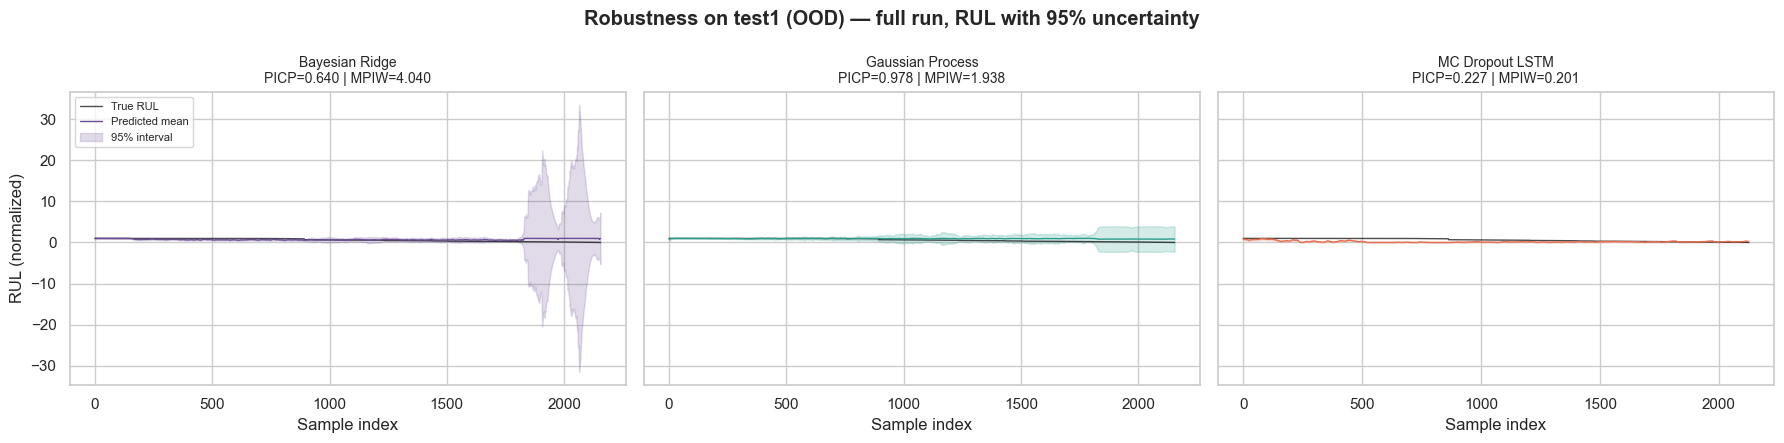

In [66]:
# One subplot per model, all sharing the same y-axis — true RUL, predicted mean,
# and a 95% band, over the full test1 (OOD) run
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
for ax, r in zip(axes, ROB_RESULTS):
    base_name = r['model_name'].split(' (')[0]
    c = colors.get(base_name, '#457b9d')
    idx_plot = np.arange(len(r['y_true']))
    ax.plot(idx_plot, r['y_true'], color='black', lw=1.0, alpha=0.7, label='True RUL')
    ax.plot(idx_plot, r['y_pred'], color=c, lw=1.0, label='Predicted mean')
    ax.fill_between(idx_plot, r['y_pred'] - 1.96 * r['sigma'], r['y_pred'] + 1.96 * r['sigma'],
                    color=c, alpha=0.2, label='95% interval')
    ax.set_title(f"{base_name}\nPICP={r['picp']:.3f} | MPIW={r['mpiw']:.3f}", fontsize=10)
    ax.set_xlabel('Sample index')
axes[0].set_ylabel('RUL (normalized)')
axes[0].legend(fontsize=8)
fig.suptitle('Robustness on test1 (OOD) — full run, RUL with 95% uncertainty', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'robustness_test1_uncertainty.png'), dpi=150, bbox_inches='tight')
plt.show()

In [68]:
# Shared y-axis limits across all 3 figures (for easy comparison)

all_lo, all_hi = [], []
for r in ROB_RESULTS:
    lo = np.minimum(r['y_true'].min(), (r['y_pred'] - 1.96 * r['sigma']).min())
    hi = np.maximum(r['y_true'].max(), (r['y_pred'] + 1.96 * r['sigma']).max())
    all_lo.append(lo)
    all_hi.append(hi)
pad = 0.05 * (max(all_hi) - min(all_lo))
Y_LIM = (min(all_lo) - pad, max(all_hi) + pad)

# retry helper — savefig can hit a transient file-lock error on some setups
def savefig_retry(path, retries=5, delay=0.8, **kwargs):
    for attempt in range(retries):
        try:
            plt.savefig(path, **kwargs)
            return
        except OSError:
            if attempt == retries - 1:
                raise
            time.sleep(delay)

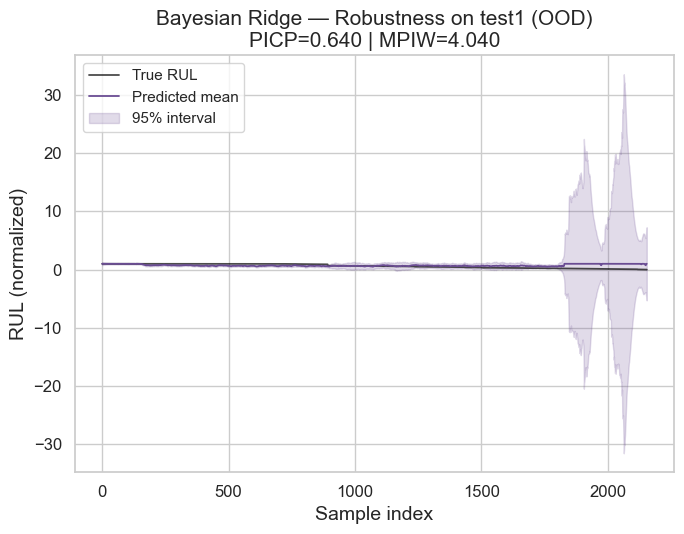

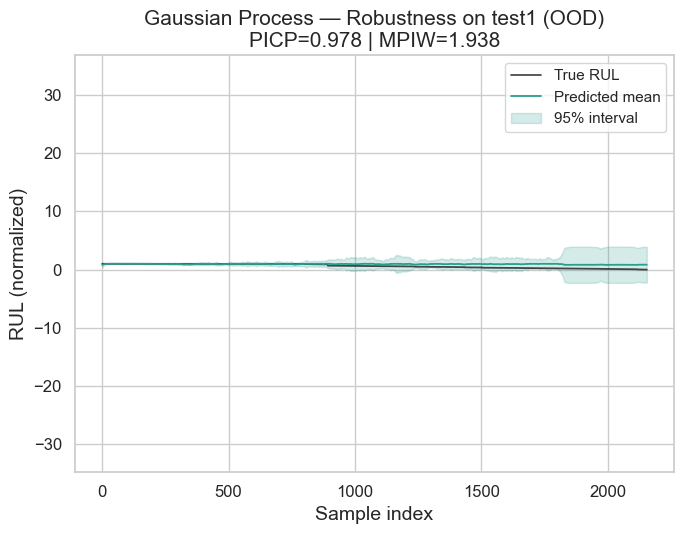

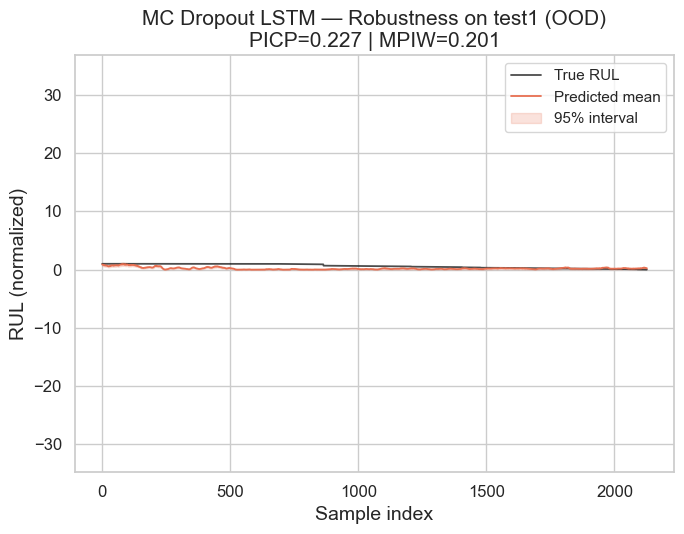

In [69]:
os.makedirs(OUT_DIR, exist_ok=True)

# One separate figure per model (was: 1x3 subplot grid), same y-scale

for r in ROB_RESULTS:
    base_name = r['model_name'].split(' (')[0]
    c = colors.get(base_name, '#457b9d')
    idx_plot = np.arange(len(r['y_true']))

    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.plot(idx_plot, r['y_true'], color='black', lw=1.3, alpha=0.7, label='True RUL')
    ax.plot(idx_plot, r['y_pred'], color=c, lw=1.3, label='Predicted mean')
    ax.fill_between(idx_plot, r['y_pred'] - 1.96 * r['sigma'], r['y_pred'] + 1.96 * r['sigma'],
                     color=c, alpha=0.2, label='95% interval')
    ax.set_ylim(Y_LIM)
    ax.set_title(f"{base_name} \u2014 Robustness on test1 (OOD)\nPICP={r['picp']:.3f} | MPIW={r['mpiw']:.3f}",
                 fontsize=15)
    ax.set_xlabel('Sample index', fontsize=14)
    ax.set_ylabel('RUL (normalized)', fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=11)
    plt.tight_layout()

    safe_name = re.sub(r'[^a-z0-9]+', '_', base_name.lower()).strip('_')
    savefig_retry(os.path.join(OUT_DIR, f'robustness_test1_{safe_name}.png'), dpi=200, bbox_inches='tight')
    plt.show()

In [ ]:
# Save robustness (test1) results
rob_summary.to_csv(os.path.join(OUT_DIR, 'robustness_test1_results.csv'), index=False)
np.savez_compressed(
    os.path.join(OUT_DIR, 'robustness_test1_predictions.npz'),
    **{f"{r['model_name'].split()[0]}__true":  r['y_true'] for r in ROB_RESULTS},
    **{f"{r['model_name'].split()[0]}__pred":  r['y_pred'] for r in ROB_RESULTS},
    **{f"{r['model_name'].split()[0]}__sigma": r['sigma']  for r in ROB_RESULTS})
print('Saved to', os.path.abspath(OUT_DIR))
print('  robustness_test1_results.csv      -> metric table (RMSE/MAE + PICP/MPIW/NLL/CRPS) on test1')
print('  robustness_test1_predictions.npz  -> per-model (true, pred, sigma) on test1')
print('  robustness_test1_uncertainty.png  -> full-run uncertainty plot, all 3 models')

#### 6. Persist Trained Models (for NB5 — Real-Time Prediction)

Saves the 3 trained models + their scalers so NB5 can load them without re-running training. GP and Bayesian Ridge are cheap to pickle directly; the LSTM backbone is already saved as `lstm_baseline.pt` in `baseline_output` (from NB3) — MC Dropout reuses those exact weights, so nothing new to save there except `seq_scaler`.

In [ ]:
# Persist the trained models + their scalers so NB5 can load them directly
import pickle as pkl

MODELS_DIR = os.path.join(OUT_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

with open(os.path.join(MODELS_DIR, 'bayesian_ridge.pkl'), 'wb') as f:
    pkl.dump(bridge_model, f)

with open(os.path.join(MODELS_DIR, 'gaussian_process.pkl'), 'wb') as f:
    pkl.dump({'model': gp_model, 'scaler': gp_scaler}, f)

with open(os.path.join(MODELS_DIR, 'seq_scaler.pkl'), 'wb') as f:
    pkl.dump(seq_scaler, f)

print('Saved trained models to', os.path.abspath(MODELS_DIR))
print('  bayesian_ridge.pkl    -> BayesianRidge model')
print('  gaussian_process.pkl  -> {model, scaler} dict (GP + its dedicated StandardScaler)')
print('  seq_scaler.pkl        -> StandardScaler for LSTM sequence input')
print('  (LSTM weights already at', os.path.join(BASELINE_DIR, 'lstm_baseline.pt'), '-- reused as-is, MC Dropout needs no retraining)')